In [1]:
import numpy as np

import struct
from array import array
from os.path import join


In [2]:
#
# MNIST Data Loader Class
#
class MnistDataloader(object):
    def __init__(
        self,
        training_images_filepath,
        training_labels_filepath,
        test_images_filepath,
        test_labels_filepath,
    ):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath

    def read_images_labels(self, images_filepath, labels_filepath):
        labels = []
        with open(labels_filepath, "rb") as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError(
                    "Magic number mismatch, expected 2049, got {}".format(magic)
                )
            labels = array("B", file.read())

        with open(images_filepath, "rb") as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError(
                    "Magic number mismatch, expected 2051, got {}".format(magic)
                )
            image_data = array("B", file.read())
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols : (i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img

        return np.array(images), np.array(labels)

    def load_data(self):
        x_train, y_train = self.read_images_labels(
            self.training_images_filepath, self.training_labels_filepath
        )
        x_test, y_test = self.read_images_labels(
            self.test_images_filepath, self.test_labels_filepath
        )
        return (x_train, y_train), (x_test, y_test)


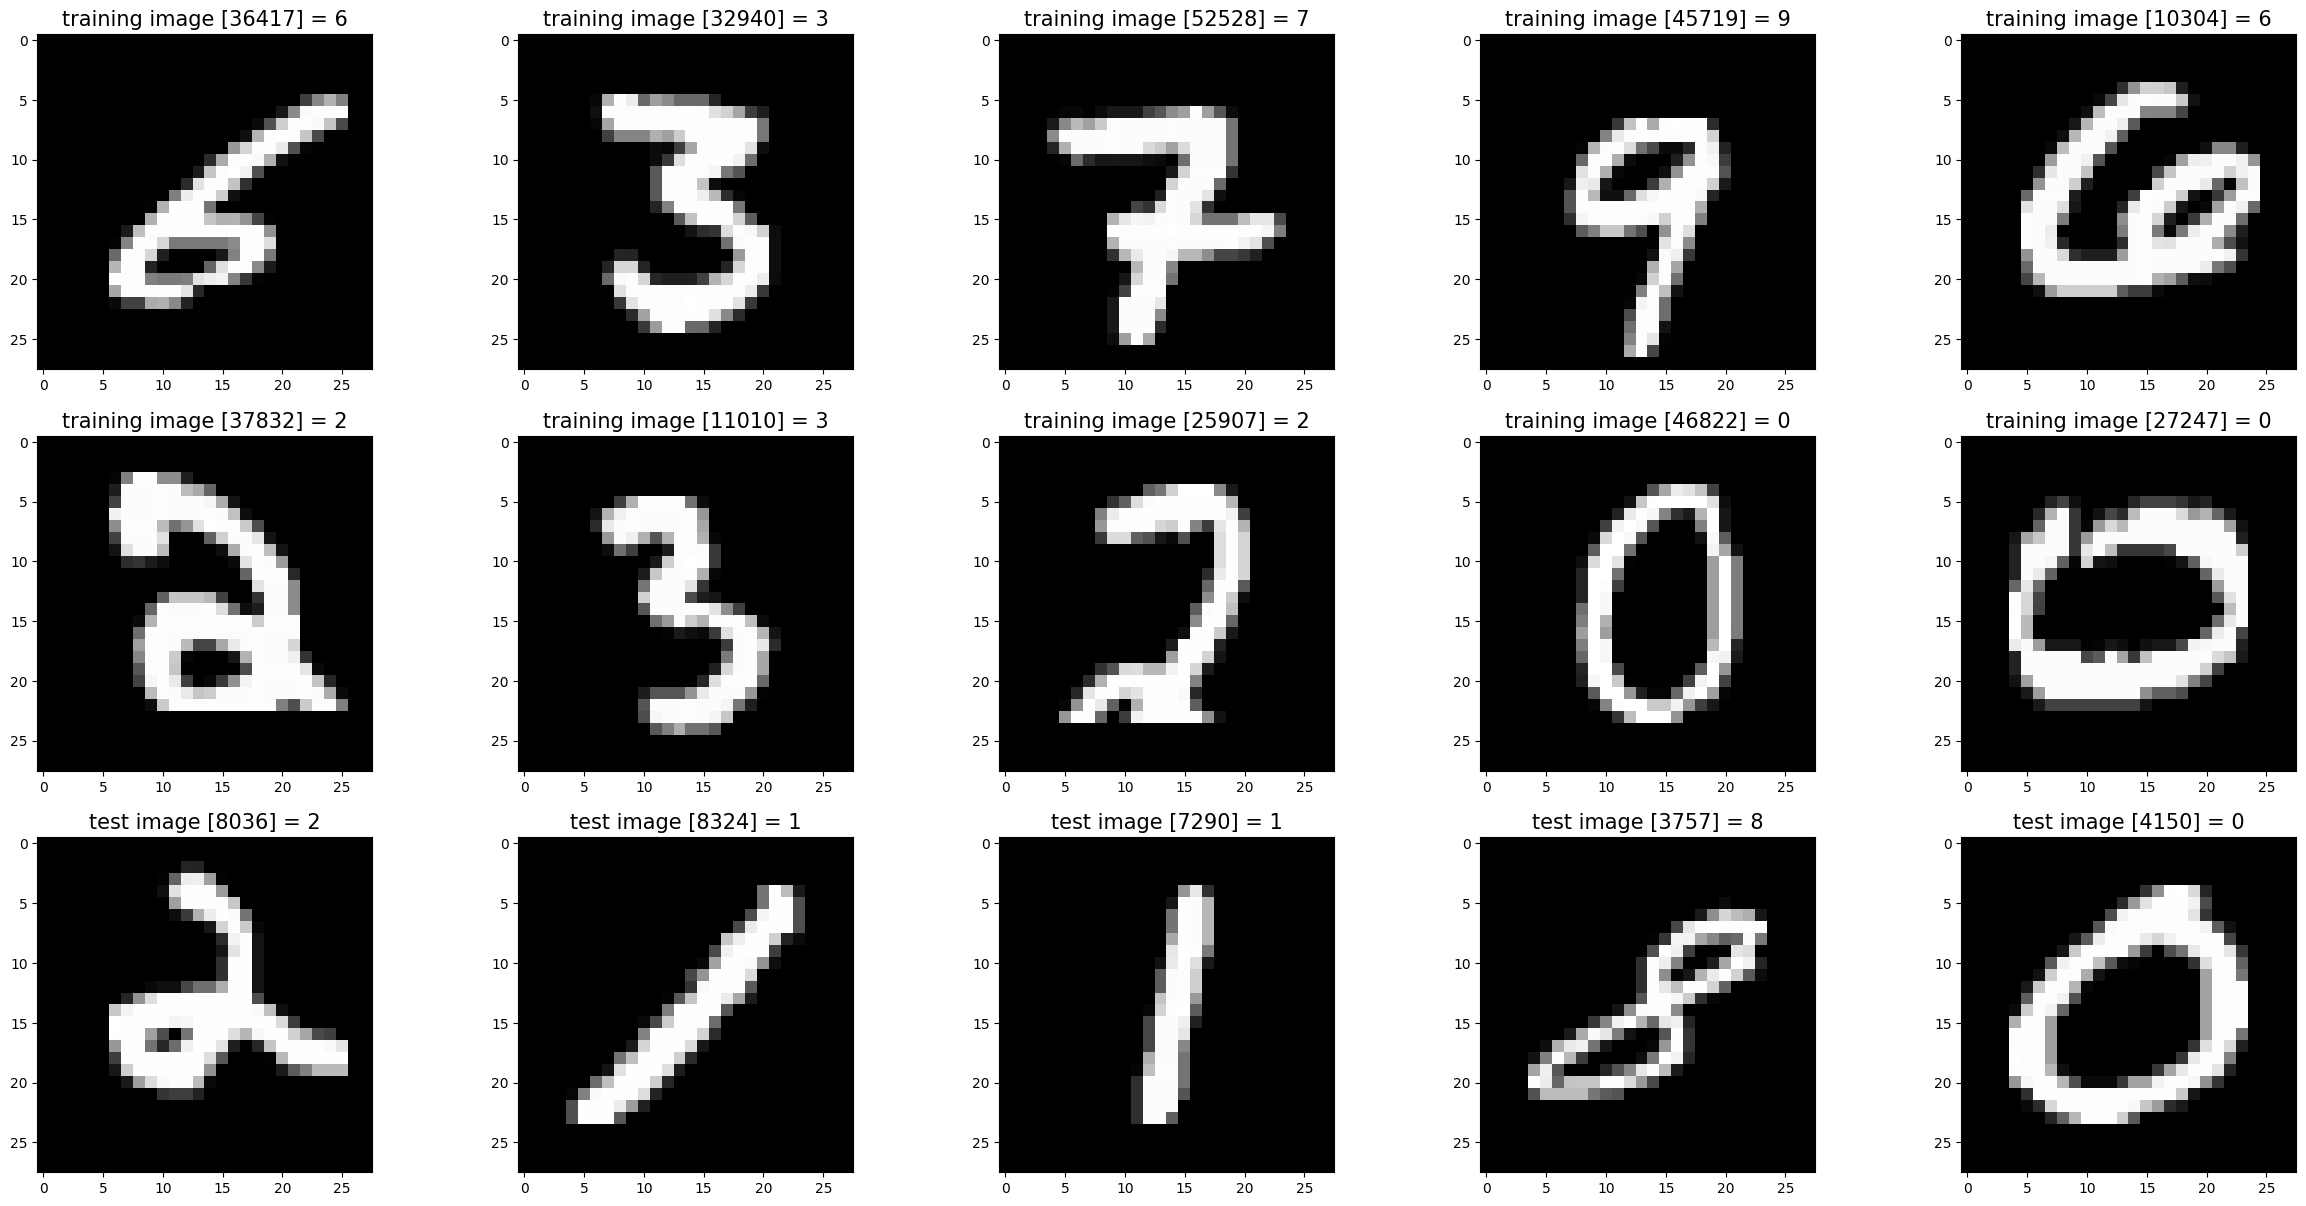

In [3]:
import random
import matplotlib.pyplot as plt

#
# Set file paths based on added MNIST Datasets
#
input_path = "."
training_images_filepath = join(
    input_path, "train-images-idx3-ubyte/train-images-idx3-ubyte"
)
training_labels_filepath = join(
    input_path, "train-labels-idx1-ubyte/train-labels-idx1-ubyte"
)
test_images_filepath = join(input_path, "t10k-images-idx3-ubyte/t10k-images-idx3-ubyte")
test_labels_filepath = join(input_path, "t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte")


#
# Helper function to show a list of images with their relating titles
#
def show_images(images, title_texts):
    cols = 5
    rows = int(len(images) / cols) + 1
    plt.figure(figsize=(30, 20))
    index = 1
    for x in zip(images, title_texts):
        image = x[0]
        title_text = x[1]
        plt.subplot(rows, cols, index)
        plt.imshow(image, cmap=plt.cm.gray)
        if title_text != "":
            plt.title(title_text, fontsize=15)
        index += 1


#
# Load MINST dataset
#
mnist_dataloader = MnistDataloader(
    training_images_filepath,
    training_labels_filepath,
    test_images_filepath,
    test_labels_filepath,
)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

#
# Show some random training and test images
#
images_2_show = []
titles_2_show = []
for i in range(0, 10):
    r = random.randint(1, 60000)
    images_2_show.append(x_train[r])
    titles_2_show.append("training image [" + str(r) + "] = " + str(y_train[r]))

for i in range(0, 5):
    r = random.randint(1, 10000)
    images_2_show.append(x_test[r])
    titles_2_show.append("test image [" + str(r) + "] = " + str(y_test[r]))

show_images(images_2_show, titles_2_show)


Now reshape the data ready for training

In [5]:
# One-hot encode labels
def one_hot(y, num_classes=10):
    return np.eye(num_classes)[y]


y_train_oh = one_hot(y_train)

x_train = x_train.reshape(60000, 28*28)

x_test = x_test.reshape(-1, 28*28)

print(x_train.shape, x_test.shape)

(60000, 784) (10000, 784)


In [6]:
# choice of activation function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def sigmoid_derivative(x):
    return x * (1 - x)

In [19]:
"""
Simple neural network. One input layer, one hidden layer, one output layer.
"""

class SimpleNN:
    def __init__(self, input_size, hidden_size, output_size):
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))

    def forward(self, X):
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = sigmoid(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = sigmoid(self.Z2)
        return self.A2

    def backward(self, X, y, output, lr=0.1):
        # compute derivatives
        m = y.shape[0]
        dZ2 = (output - y) * sigmoid_derivative(output)
        dW2 = self.A1.T @ dZ2 / m
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dZ1 = dZ2 @ self.W2.T * sigmoid_derivative(self.A1)
        dW1 = X.T @ dZ1 / m
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # update weights
        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1

In [37]:
"""
Simple neural network. One input layer, one hidden layer, one output layer.
"""

class SimpleNN:
    def __init__(self, input_size, hidden_size, output_size):
        self.A1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.A2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))

    def forward(self, X):
        self.Y_tilde = X @ self.A1 + self.b1
        self.Y = sigmoid(self.Y_tilde)
        self.Z_tilde = self.Y @ self.A2 + self.b2
        self.Z = sigmoid(self.Z_tilde)
        return self.Z

    def backward(self, X, Z_data, Z, lr=0.1):
        # compute derivatives
        d_loss = (Z - Z_data) * sigmoid_derivative(self.Z_tilde)
        print(f"{self.A2.shape}, {d_loss.shape}, {Z.shape} {Z_data.shape}")
        dA2 = self.A2 @ d_loss
        db2 = d_loss

        dA1 = dA2 @ sigmoid_derivative(self.Y_tilde) @ X
        db2 = db2 @ sigmoid_derivative(self.Y_tilde)
        
        # update weights
        self.A2 -= lr * dA2
        self.b2 -= lr * db2
        self.A2 -= lr * dA1
        self.b1 -= lr * db1

In [38]:
nn = SimpleNN(784, 600, 10)
epochs = 10
learning_rate = 1.0e-3

# do training
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

for epoch in range(epochs):
    # Forward pass on the entire training set
    output = nn.forward(x_train)
    
    # Backward pass and weight update
    nn.backward(x_train, y_train_oh, output, lr=learning_rate)
    
    # Evaluate loss
    loss = mse_loss(y_train_oh, output)
    print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

(600, 10), (60000, 10), (60000, 10) (60000, 10)


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 60000 is different from 10)

In [34]:
# validate on test set
test_output = nn.forward(x_test)
predictions = np.argmax(test_output, axis=1)
accuracy = np.mean(predictions == y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 11.58%


[0.00176488 0.00420702 0.00109081 0.00157691 0.00219612 0.00236857
 0.00224693 0.00352231 0.00401654 0.00312427]
[0.00128826 0.00550269 0.00111231 0.00177177 0.00218588 0.00335027
 0.0024763  0.00376979 0.00369776 0.00367534]
[0.00128289 0.005564   0.00102323 0.00212881 0.00253886 0.00305888
 0.00199733 0.00396575 0.00298125 0.00377389]
[0.00103004 0.00448996 0.00142344 0.00187856 0.00214787 0.00337581
 0.00264376 0.00389829 0.0036439  0.00372046]
[0.00112615 0.00499042 0.00115051 0.00198603 0.0020768  0.00292889
 0.00248322 0.00391421 0.00383008 0.00326565]


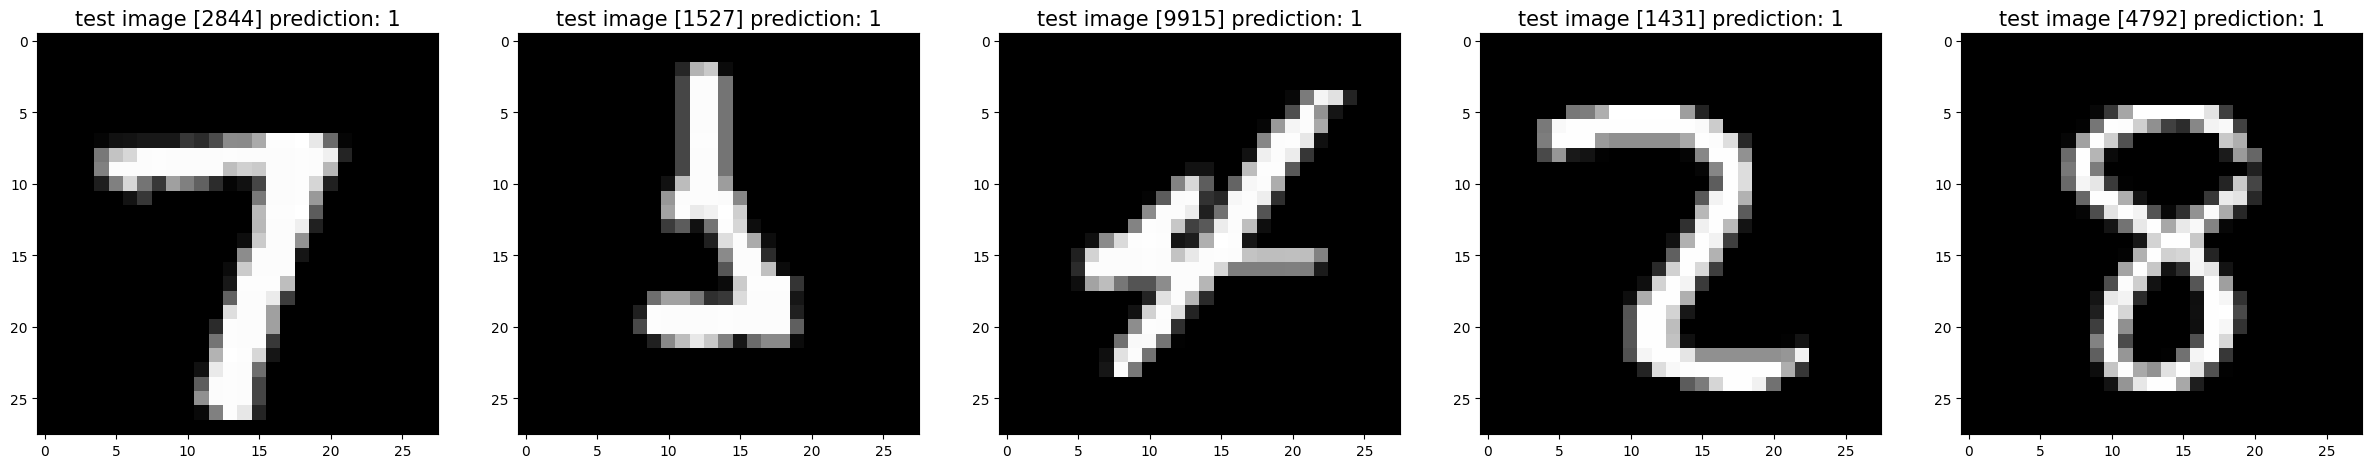

In [25]:
#
# Show some random training and test images
#
images_2_show = []
titles_2_show = []
for i in range(0, 5):
    r = random.randint(1, 10000)
    images_2_show.append(x_test[r].reshape(28, 28))
    titles_2_show.append(f"test image [{r}] prediction: {predictions[r]}")
    print(test_output[r])

show_images(images_2_show, titles_2_show)